# Gaussian Processes Summer School

## Part 5: Non-stationary Kernels

<a href="https://www.uc3m.es/"><img src="./uc3m.png" alt="Universidad Carlos III de Madrid" width="520"></a>

**Author:** [Pablo M. Olmos](https://olmos-pm.github.io/)  
**Email:** [pamartin@ing.uc3m.es](mailto:pamartin@ing.uc3m.es)

---

### A one-dimensional Gaussian process with input-dependent smoothness

We construct a collection of signals that are smooth on the left of the input domain and progressively rougher on the right. The change is produced by a valid non-stationary covariance function, not by stitching together unrelated processes.

## Learning goals

1. Distinguish stationarity from non-stationarity in a covariance function.
2. Use the Gibbs kernel to encode a lengthscale that varies with the input.
3. Sample a database of signals from the resulting GP.
4. Diagnose non-stationarity from sample paths, the covariance matrix, and local covariance slices.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

seed = 7
rng = np.random.default_rng(seed)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. From stationary to non-stationary covariance

A stationary kernel has the form

$$k(x,x')=k(x-x').$$

Consequently, every pair of inputs separated by the same lag has the same covariance, regardless of where that pair lies. For example, an RBF kernel uses one global lengthscale $\ell$:

$$k_{\mathrm{RBF}}(x,x')=\sigma_f^2\exp\left[-\frac{(x-x')^2}{2\ell^2}\right].$$

To allow the local smoothness to change with position, we replace the global lengthscale with a positive function $\ell(x)$. A valid covariance that implements this idea is the one-dimensional **Gibbs kernel**:

$$
k_{\mathrm{Gibbs}}(x,x')=\sigma_f^2
\sqrt{\frac{2\ell(x)\ell(x')}{\ell(x)^2+\ell(x')^2}}
\exp\left[-\frac{(x-x')^2}{\ell(x)^2+\ell(x')^2}\right].
$$

It reduces to the RBF kernel when $\ell(x)$ is constant. Otherwise it depends on the absolute locations $x$ and $x'$, so it is non-stationary. Its diagonal remains $k(x,x)=\sigma_f^2$: only smoothness changes here, while marginal signal variance stays constant.

### Intuition for the square-root term

The factor

$$c(x,x')=\sqrt{\frac{2\ell(x)\ell(x')}{\ell(x)^2+\ell(x')^2}}$$

measures how compatible the two **local notions of smoothness** are. Imagine that each input carries a Gaussian smoothing window whose width is $\ell(x)$. By the arithmetic--geometric mean inequality,

$$0<c(x,x')\leq 1.$$

If $\ell(x)=\ell(x')$, then $c(x,x')=1$: the two locations agree about the local scale and no penalty is needed. If one lengthscale is much larger than the other, then $c(x,x')$ approaches zero: a very smooth region and a very rough region share less covariance than distance alone would suggest. At $x=x'$, both lengthscales are necessarily equal, so the factor is exactly one and preserves $k(x,x)=\sigma_f^2$. This term is also part of what makes the input-dependent construction a valid positive-definite kernel; simply inserting a varying lengthscale into an RBF exponent would not generally be sufficient.

### Design an input-dependent lengthscale

We use a decreasing logistic transition,

$$\ell(x)=\ell_{\min}+(\ell_{\max}-\ell_{\min})\,\frac{1}{1+\exp(sx)},$$

with $\ell_{\max}=0.80$, $\ell_{\min}=0.08$, and $s=2$. The GP is therefore smooth on the left, changes regime around zero, and is rough on the right.

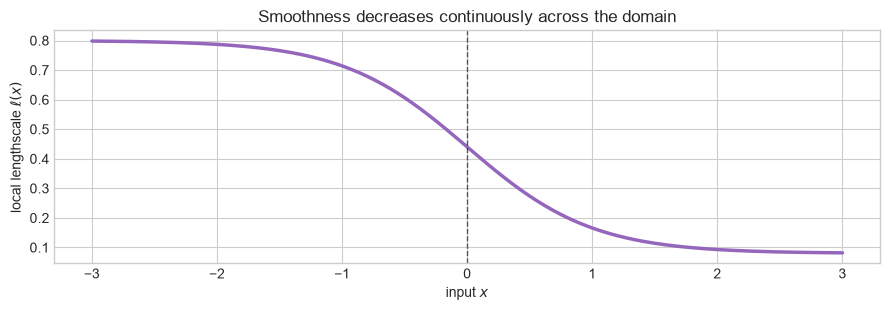

In [8]:
n_points = 200
x = np.linspace(-3.0, 3.0, n_points)

ell_min = 0.08
ell_max = 0.80
transition_steepness = 2.0
signal_std = 1.0
noise_std = 0.03

def lengthscale_function(x):
    return ell_min + (ell_max - ell_min) / (1.0 + np.exp(transition_steepness * x))

local_lengthscale = lengthscale_function(x)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(x, local_lengthscale, linewidth=2.5, color="tab:purple")
ax.axvline(0.0, color="black", linewidth=1, linestyle="--", alpha=0.6)
ax.set(xlabel=r"input $x$", ylabel=r"local lengthscale $\ell(x)$",
       title="Smoothness decreases continuously across the domain")
fig.tight_layout()
plt.show()

### Build the covariance and sample the dataset

Every curve below is an independent draw from the same GP,

$$f_i\sim\mathcal{GP}(0,k_{\mathrm{Gibbs}}),\qquad y_i(x)=f_i(x)+\epsilon_i(x),$$

where $\epsilon_i(x)\sim\mathcal N(0,\sigma_n^2)$. Thus the location of the smooth-to-rough transition is shared by the entire population; the particular shape of each curve is random.

In [9]:
def gibbs_kernel(x1, x2, lengthscale_fn, outputscale=1.0):
    x1 = np.asarray(x1, dtype=float)[:, None]
    x2 = np.asarray(x2, dtype=float)[None, :]
    ell1 = lengthscale_fn(x1)
    ell2 = lengthscale_fn(x2)
    ell_squared_sum = ell1**2 + ell2**2
    normalization = np.sqrt(2.0 * ell1 * ell2 / ell_squared_sum)
    return outputscale**2 * normalization * np.exp(-(x1 - x2)**2 / ell_squared_sum)

K = gibbs_kernel(x, x, lengthscale_function, outputscale=signal_std)
K = 0.5 * (K + K.T)  # remove floating-point asymmetry

n_signals = 300
jitter = 1e-9
L = np.linalg.cholesky(K + jitter * np.eye(n_points))
latent_signals = rng.standard_normal((n_signals, n_points)) @ L.T
observed_signals = latent_signals + noise_std * rng.standard_normal(latent_signals.shape)

dataset_summary = pd.DataFrame({
    "quantity": ["signals", "points per signal", "input interval",
                 "min / max lengthscale", "signal std", "noise std"],
    "value": [n_signals, n_points, "[-3, 3]",
              f"{local_lengthscale.min():.3f} / {local_lengthscale.max():.3f}",
              signal_std, noise_std],
})
display(dataset_summary)
print("latent_signals shape:", latent_signals.shape)
print("observed_signals shape:", observed_signals.shape)

,quantity,value
0,signals,300
1,points per signal,200
2,input interval,"[-3, 3]"
3,min / max lengthscale,0.082 / 0.798
4,signal std,1.0
5,noise std,0.03


latent_signals shape: (300, 200)
observed_signals shape: (300, 200)


### Sample paths

The large lengthscale on the left suppresses rapid variation. On the right, nearby inputs decorrelate much faster and the paths develop fine-scale structure. The faint dots show noisy observations and the solid lines show their latent GP functions.

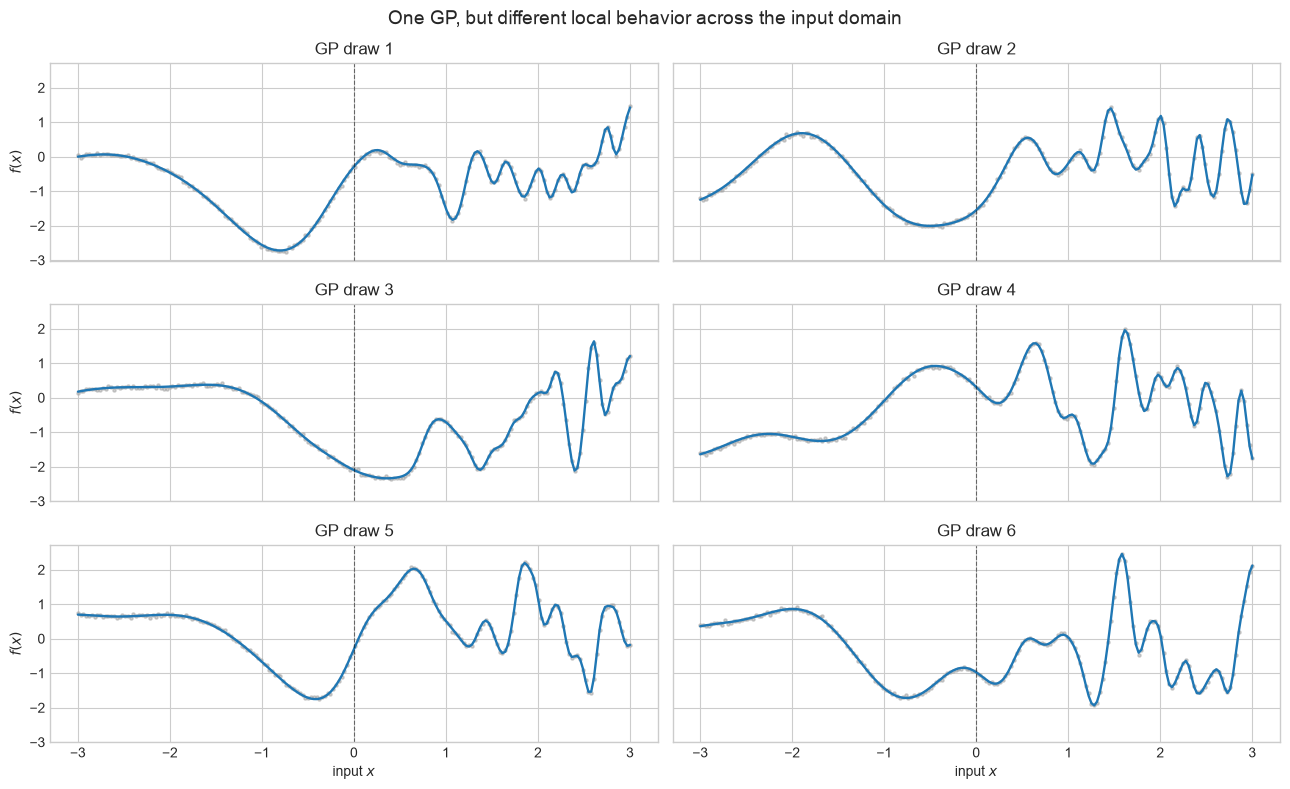

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(13, 8), sharex=True, sharey=True)
for signal_index, ax in enumerate(axes.flat):
    ax.scatter(x, observed_signals[signal_index], s=5, color="0.65", alpha=0.55)
    ax.plot(x, latent_signals[signal_index], linewidth=1.7, color="tab:blue")
    ax.axvline(0.0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_title(f"GP draw {signal_index + 1}")
for ax in axes[-1]:
    ax.set_xlabel(r"input $x$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$f(x)$")
fig.suptitle("One GP, but different local behavior across the input domain", fontsize=14)
fig.tight_layout()
plt.show()

### The equal-lag test

Stationarity would require $k(x_0,x_0+\tau)$ to be identical for every anchor location $x_0$. We evaluate it around three anchors. The covariance decays slowly at $x_0=-2$, moderately at $x_0=0$, and rapidly at $x_0=2$. This directly disproves stationarity.

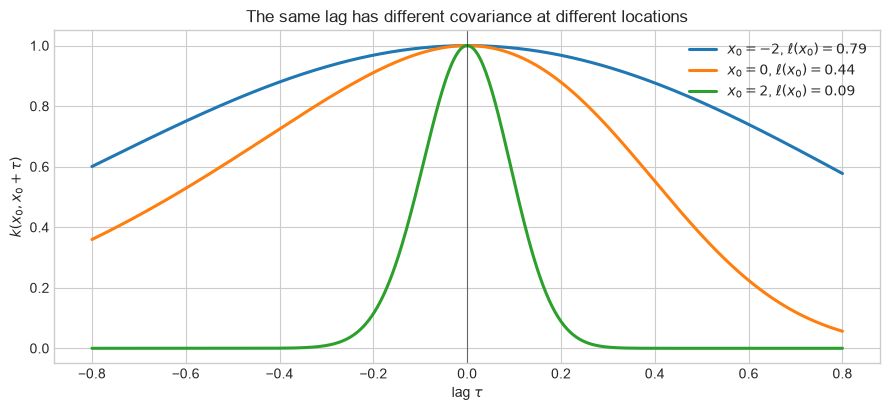

In [7]:
anchors = [-2.0, 0.0, 2.0]
tau = np.linspace(-0.8, 0.8, 500)

fig, ax = plt.subplots(figsize=(9, 4.2))
for anchor in anchors:
    covariance_slice = gibbs_kernel(
        np.array([anchor]), anchor + tau, lengthscale_function, signal_std
    ).ravel()
    ax.plot(tau, covariance_slice, linewidth=2.2,
            label=rf"$x_0={anchor:g}$, $\ell(x_0)={lengthscale_function(anchor):.2f}$")
ax.axvline(0.0, color="black", linewidth=0.8, alpha=0.5)
ax.set(xlabel=r"lag $\tau$", ylabel=rf"$k(x_0,x_0+\tau)$",
       title="The same lag has different covariance at different locations")
ax.legend()
fig.tight_layout()
plt.show()

### See non-stationarity in the covariance matrix

For a stationary RBF kernel sampled on a regular grid, the covariance matrix has a constant-width band along its diagonal. Here that band is wide in the upper-left region and narrow in the lower-right region: correlation persists over larger distances on the left than on the right.

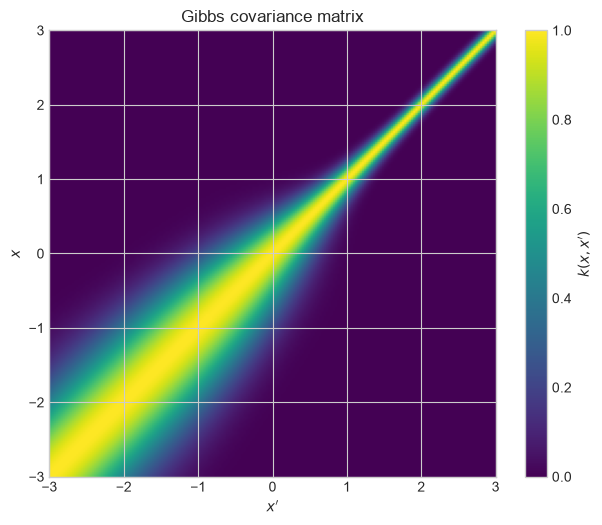

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5.3))
image = ax.imshow(K, origin="lower", extent=[x.min(), x.max(), x.min(), x.max()],
                  cmap="viridis", vmin=0.0, vmax=signal_std**2, aspect="equal")
ax.set(xlabel=r"$x'$", ylabel=r"$x$", title="Gibbs covariance matrix")
fig.colorbar(image, ax=ax, label=r"$k(x,x')$")
fig.tight_layout()
plt.show()

## Takeaway

This dataset has one deliberately isolated source of non-stationarity: its local lengthscale. All signals share the same zero mean, constant marginal variance, and smooth-to-rough transition. The variables `x`, `latent_signals`, `observed_signals`, `local_lengthscale`, and `K` are ready for the modeling experiments that follow.